# CNN
## Convolutional Neural Networks
### Master of Science in Data Science — LUISS Guido Carli

---

This notebook is divided into two parts, each covering ~1.5 hours of class time.

| Part | Topic | Duration |
|------|-------|----------|
| **Part 1** | CNN fundamentals + MNIST classifier | ~90 min |
| **Part 2** | CNN 1D, CNN 3D, Data Augmentation, Transfer Learning | ~90 min |

> **How to use this notebook:** cells marked with `# TODO` are for you to fill in.  
> Work through them together during the lab session.


---
# PART 1 — CNN Fundamentals & MNIST Classifier
---

## 1.0 Environment Setup

In [3]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version:      {keras.__version__}")
print(f"GPU available:      {len(tf.config.list_physical_devices('GPU')) > 0}")


TensorFlow version: 2.20.0
Keras version:      3.13.2
GPU available:      False


---
## 1.1 Motivation — Why Not Just Dense Networks?

In the previous lecture you built a **fully-connected (dense) neural network** to classify MNIST digits.  
Each of the 784 pixels was connected to every neuron in the first hidden layer.

**The problem:** dense networks ignore the *spatial structure* of images.  
They treat pixel (0,0) and pixel (27,27) as equally related — which is clearly wrong.

> **Key insight:** nearby pixels are correlated. A CNN exploits this by learning *local filters*.


In [4]:
# ── Load MNIST ────────────────────────────────────────────────────────────
(X_train_raw, y_train), (X_test_raw, y_test) = mnist.load_data()

print(f"Training set shape : {X_train_raw.shape}  → {X_train_raw.shape[0]} images of {X_train_raw.shape[1]}×{X_train_raw.shape[2]} pixels")
print(f"Test set shape     : {X_test_raw.shape}")
print(f"Labels             : {np.unique(y_train)}  (digits 0-9)")


Training set shape : (60000, 28, 28)  → 60000 images of 28×28 pixels
Test set shape     : (10000, 28, 28)
Labels             : [0 1 2 3 4 5 6 7 8 9]  (digits 0-9)


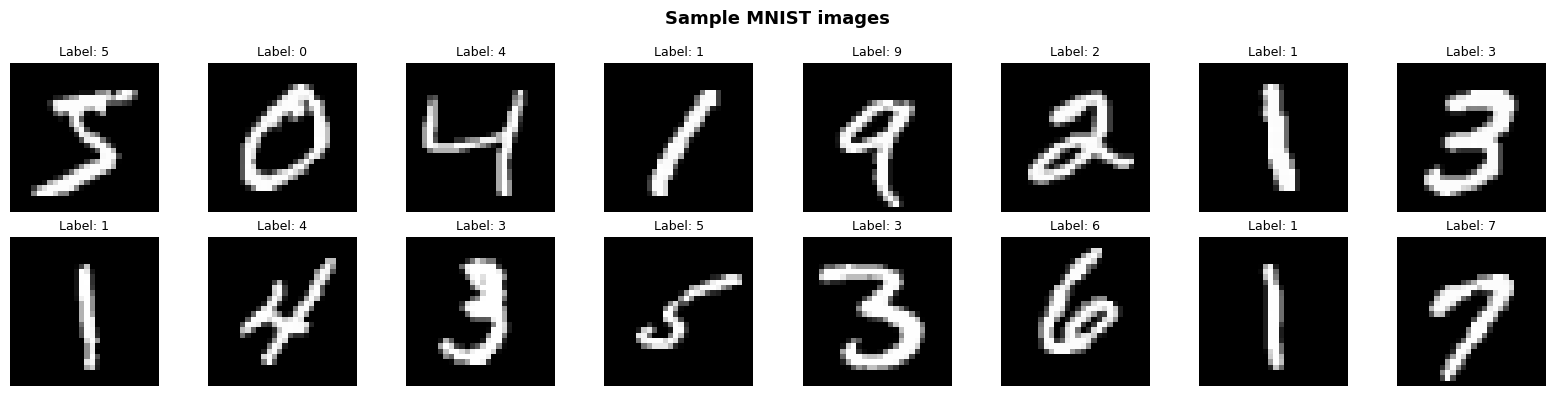

In [5]:
# ── Visualise a few samples ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train_raw[i], cmap='gray')
    ax.set_title(f"Label: {y_train[i]}", fontsize=9)
    ax.axis('off')
plt.suptitle("Sample MNIST images", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 1.2 Step 1 — The Convolution Operation

A **filter** (or *kernel*) is a small matrix of learnable weights.  
It *slides* over the input image, computing a **dot product** at each position → this produces a **Feature Map**.

$$\text{Feature Map}[i,j] = \sum_{m}\sum_{n} \text{Image}[i{+}m,\, j{+}n] \cdot \text{Filter}[m,n]$$

Key concepts:
- **Stride**: how many pixels the filter moves at each step (larger stride → smaller output)
- **Padding**: adding zeros around the border to control output size  
  - `'valid'`: no padding (output shrinks)  
  - `'same'` : padding added to keep output size equal to input


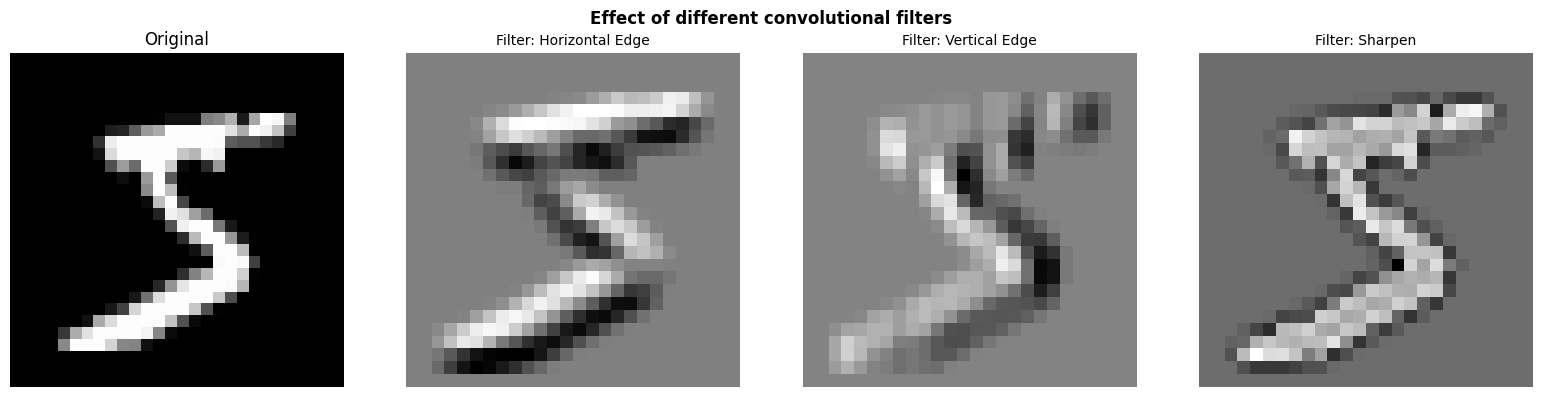

In [6]:
# ── Manual convolution demo ───────────────────────────────────────────────
from scipy.ndimage import convolve

def manual_conv(image, kernel, stride=1):
    """Apply a 2D convolution manually (for illustration only)."""
    kH, kW = kernel.shape
    iH, iW = image.shape
    oH = (iH - kH) // stride + 1
    oW = (iW - kW) // stride + 1
    output = np.zeros((oH, oW))
    for i in range(0, oH):
        for j in range(0, oW):
            patch = image[i*stride:i*stride+kH, j*stride:j*stride+kW]
            output[i, j] = np.sum(patch * kernel)
    return output

# Example image
sample_img = X_train_raw[0].astype(float)

# Three classic filters
filters = {
    "Horizontal Edge": np.array([[-1,-1,-1],[0,0,0],[1,1,1]], dtype=float),
    "Vertical Edge" : np.array([[-1,0,1],[-1,0,1],[-1,0,1]], dtype=float),
    "Sharpen"       : np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=float),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(sample_img, cmap='gray'); axes[0].set_title("Original"); axes[0].axis('off')
for ax, (name, f) in zip(axes[1:], filters.items()):
    result = manual_conv(sample_img, f)
    ax.imshow(result, cmap='gray')
    ax.set_title(f"Filter: {name}", fontsize=10)
    ax.axis('off')
plt.suptitle("Effect of different convolutional filters", fontweight='bold')
plt.tight_layout(); plt.show()


### 📝 Task 1.2 — Toy Convolution

Complete the function below to compute the convolution of the 5×5 image with the 3×3 filter  
(stride = 1, no padding). The expected output is a **3×3 Feature Map**.


In [7]:
# ── Task 1.2 ─────────────────────────────────────────────────────────────
image_toy = np.array([
    [1, 1, 1, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 1, 1, 1],
    [0, 0, 1, 1, 0],
    [0, 1, 1, 0, 0]
], dtype=float)

filter_toy = np.array([
    [1, 0, 1],
    [0, 1, 0],
    [1, 0, 1]
], dtype=float)

def compute_feature_map(image, kernel, stride=1):
    """
    Compute 2D convolution with stride=1 and no padding.
    
    Returns
    -------
    np.ndarray of shape ((H-kH+1), (W-kW+1))
    """
    kH, kW = kernel.shape
    iH, iW = image.shape
    oH = iH - kH + 1
    oW = iW - kW + 1

    # TODO: fill in the nested loop to compute the feature map
    # Hint: for each position (i,j) compute the dot product of the patch and the kernel
    # Ho solo copiato quello che era scritto sopra
    output = np.zeros((oH, oW))
    for i in range(oH):          # slide vertically
        for j in range(oW):      # slide horizontally
        # The patch is the sub-image the kernel currently overlaps
            patch = image[i : i + kH,
                      j : j + kW]
        # Element-wise multiply then sum → one scalar per position
            output[i, j] = np.sum(patch * kernel)
    return output

feature_map = compute_feature_map(image_toy, filter_toy)
print("Feature Map:")
print(feature_map)
print("\nExpected: [[4,3,4],[2,4,3],[2,3,4]]")


Feature Map:
[[4. 3. 4.]
 [2. 4. 3.]
 [2. 3. 4.]]

Expected: [[4,3,4],[2,4,3],[2,3,4]]


---
## 1.3 Step 1b — ReLU Activation

After each convolution we apply **ReLU** (Rectified Linear Unit):

$$\text{ReLU}(x) = \max(0, x)$$

**Why?**
1. Introduces *non-linearity* — without it, stacking layers is equivalent to a single linear transformation
2. Prevents *vanishing gradients* (unlike sigmoid/tanh)
3. Computationally efficient (simple threshold at 0)
4. Helps satisfy the *independence assumption* of abstract representations in hidden layers


### 📝 Task 1.3 — Visualise ReLU

Apply ReLU to the feature map obtained with the **Horizontal Edge** filter and plot the result.


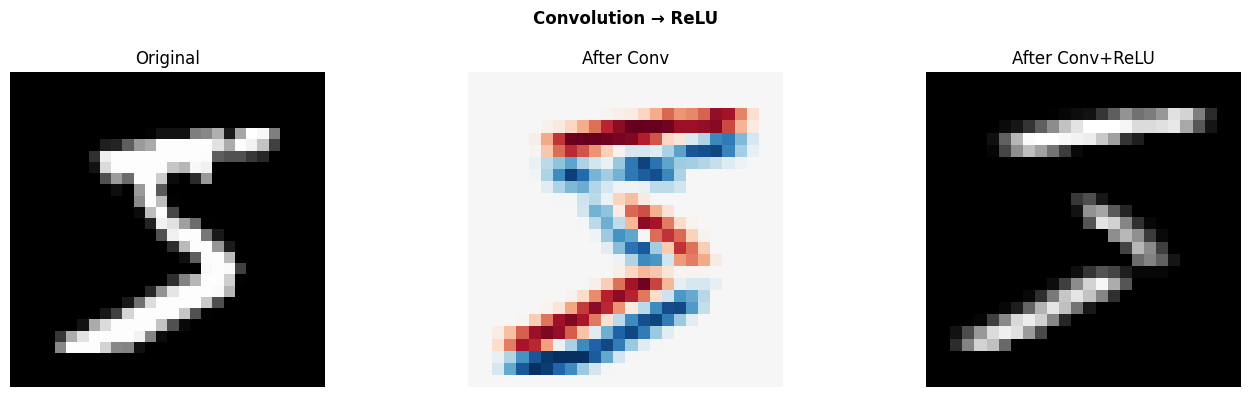

In [8]:
# ── Task 1.3 ─────────────────────────────────────────────────────────────

# Step 1: compute the feature map using the Horizontal Edge filter
h_edge_filter = np.array([[-1,-1,-1],[0,0,0],[1,1,1]], dtype=float)
feature_map_h = manual_conv(sample_img, h_edge_filter)

# TODO: apply ReLU to feature_map_h
# replace with your implementation
feature_map_relu = np.maximum(0, feature_map_h)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(sample_img, cmap='gray');         axes[0].set_title("Original");        axes[0].axis('off')
axes[1].imshow(feature_map_h, cmap='RdBu_r');   axes[1].set_title("After Conv");      axes[1].axis('off')
axes[2].imshow(feature_map_relu, cmap='gray');   axes[2].set_title("After Conv+ReLU"); axes[2].axis('off')
plt.suptitle("Convolution → ReLU", fontweight='bold')
plt.tight_layout(); plt.show()


---
## 1.4 Step 2 — Pooling

**Pooling** reduces the spatial size of the feature map:
- **Max Pooling**: takes the *maximum* value in each pooling window → preserves the most prominent feature
- **Average Pooling**: takes the *average* value → smoother summary

Benefits:
- Reduces computational cost
- Builds *translation invariance* (small shifts in input don't change output)
- No learnable parameters!

Common setting: 2×2 window, stride 2 → halves each spatial dimension.


### 📝 Task 1.4 — Implement Max Pooling

Complete `max_pool_2x2` and apply it to the ReLU feature map from the previous step.


Before pooling : (26, 26)
After pooling  : (13, 13)


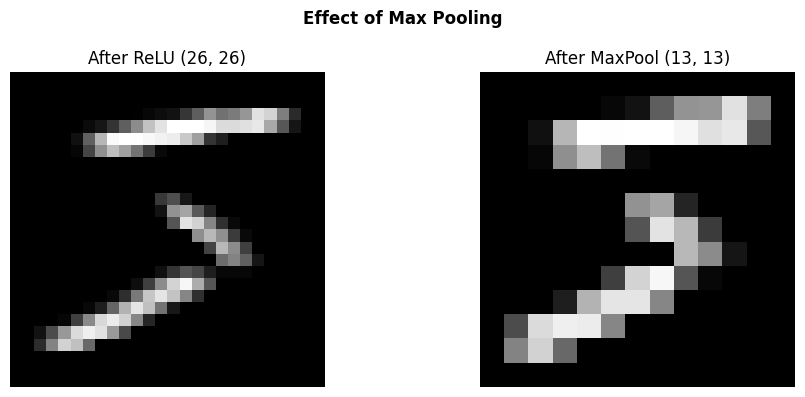

In [9]:
# ── Task 1.4 ─────────────────────────────────────────────────────────────

def max_pool_2x2(feature_map):
    """
    Apply 2×2 max pooling with stride 2 (no overlap).
    
    Returns
    -------
    np.ndarray of shape (H//2, W//2)
    """
    H, W = feature_map.shape
    out_H = H // 2
    out_W = W // 2
    output = np.zeros((out_H, out_W))
    
    # TODO: fill in the nested loop
    # Hint: for each 2×2 block, take the maximum value
    for i in range(out_H):
        for j in range(out_W):
            # Extract the 2×2 window starting at position (2i, 2j)
            window = feature_map[i*2 : i*2+2,
                                 j*2 : j*2+2]
            # Keep only the strongest activation in this local region
            output[i, j] = np.max(window)
    
    return output

# TODO: use the ReLU map you computed in Task 1.3
pooled = max_pool_2x2(feature_map_relu)

print(f"Before pooling : {feature_map_relu.shape}")
print(f"After pooling  : {pooled.shape}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(feature_map_relu, cmap='gray'); axes[0].set_title(f"After ReLU {feature_map_relu.shape}"); axes[0].axis('off')
axes[1].imshow(pooled, cmap='gray');           axes[1].set_title(f"After MaxPool {pooled.shape}");        axes[1].axis('off')
plt.suptitle("Effect of Max Pooling", fontweight='bold')
plt.tight_layout(); plt.show()


---
## 1.5 Steps 3 & 4 — Flattening and Full Connection

**Flattening**: convert the 2D feature maps into a 1D vector so it can be fed into a dense layer.  
**Full Connection**: one or more dense layers that combine the learned features and output class probabilities.

The full CNN pipeline for classification:

```
Input Image
    ↓  Conv2D + ReLU
Feature Maps
    ↓  MaxPooling2D
Downsampled Feature Maps
    ↓  (repeat Conv+Pool blocks)
    ↓  Flatten
1D Feature Vector
    ↓  Dense + ReLU
    ↓  Dense + Softmax
Class Probabilities  (10 classes for MNIST)
```


---
## 1.6 Building a CNN for MNIST

### Data Preprocessing


In [10]:
# ── Preprocessing ─────────────────────────────────────────────────────────

# Reshape to (N, H, W, C)  — Keras Conv2D expects a channel dimension
X_train = X_train_raw.reshape(-1, 28, 28, 1).astype('float32')
X_test  = X_test_raw.reshape(-1, 28, 28, 1).astype('float32')

# TODO: Normalise pixel values to the range [0, 1]
X_train = X_train/ 255  # replace with your code
X_test  = X_test/ 255  # replace with your code

# One-hot encode labels
from tensorflow.keras.utils import to_categorical
y_train_oh = to_categorical(y_train, 10)
y_test_oh  = to_categorical(y_test,  10)

print(f"X_train shape : {X_train.shape}")
print(f"y_train_oh shape : {y_train_oh.shape}")
print(f"Pixel min={X_train.min():.2f}  max={X_train.max():.2f}")


X_train shape : (60000, 28, 28, 1)
y_train_oh shape : (60000, 10)
Pixel min=0.00  max=1.00


### 📝 Task 1.6a — Define the CNN Architecture

Build the following CNN using Keras **Sequential API**:

| Layer | Type | Parameters |
|-------|------|-----------|
| 1 | Conv2D | 32 filters, 3×3 kernel, ReLU, same padding |
| 2 | MaxPooling2D | 2×2 pool size |
| 3 | Conv2D | 64 filters, 3×3 kernel, ReLU, same padding |
| 4 | MaxPooling2D | 2×2 pool size |
| 5 | Flatten | — |
| 6 | Dense | 128 units, ReLU |
| 7 | Dropout | rate = 0.5 |
| 8 | Dense | 10 units, Softmax |


In [11]:
# ── Task 1.6a ─────────────────────────────────────────────────────────────

def build_cnn(input_shape=(28, 28, 1), num_classes=10):
    model = models.Sequential(name="MNIST_CNN")
    
    # TODO: add the layers according to the table above
    # Block 1
    # ── Conv Block 1 ──────────────────────────────────────────────────────
    # 32 filters of size 3×3.  padding='same' → output stays 28×28.
    # activation='relu' applies ReLU automatically after the linear operation.
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same',input_shape=input_shape))

    # Halve spatial dimensions: 28×28 → 14×14.  No learnable params.
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    
    # ── Conv Block 2 ──────────────────────────────────────────────────────
    # 64 filters — more capacity to detect complex combinations of edges/curves
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))

    # 14×14 → 7×7
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # ── Classifier Head ───────────────────────────────────────────────────
    # Convert 7×7×64 = 3136-dimensional tensor into a 1D vector
    model.add(layers.Flatten())

    # Fully-connected layer: learns task-specific combinations of features
    model.add(layers.Dense(128, activation='relu'))

    # Dropout: randomly zero 50% of neurons during training only.
    # At inference time Dropout is automatically disabled.
    model.add(layers.Dropout(rate=0.5))

    # Output layer: one neuron per class, Softmax gives probabilities summing to 1
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

model = build_cnn()
model.summary()


Model: "MNIST_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

### **NOTE**: the real neural network part is the part after the flatten layer, where the ANN starts (before we are only applying convolutions)             
Put all together is called CNN.

### 📝 Task 1.6b — Compile the Model

Compile the model using:
- **Optimizer**: Adam with learning rate 0.001
- **Loss**: categorical cross-entropy
- **Metric**: accuracy


In [12]:
# ── Task 1.6b ─────────────────────────────────────────────────────────────

# TODO: compile the model
model.compile(optimizer=keras.optimizers.Adam(), loss='categorical_crossentropy', metrics=['accuracy'])



### 📝 Task 1.6c — Train the Model

Train for **10 epochs** with a batch size of **128**, using 20% of the training data for validation.


In [13]:
# ── Task 1.6c ─────────────────────────────────────────────────────────────

# TODO: fit the model and store the history in a variable called `history`
# replace with your code
history = model.fit(X_train, y_train_oh, epochs=10, batch_size=128, validation_split=0.2, verbose=1)  



Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - accuracy: 0.8972 - loss: 0.3305 - val_accuracy: 0.9751 - val_loss: 0.0819
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.9695 - loss: 0.1074 - val_accuracy: 0.9833 - val_loss: 0.0539
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.9765 - loss: 0.0776 - val_accuracy: 0.9869 - val_loss: 0.0449
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.9810 - loss: 0.0642 - val_accuracy: 0.9884 - val_loss: 0.0395
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.9832 - loss: 0.0555 - val_accuracy: 0.9877 - val_loss: 0.0401
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.9852 - loss: 0.0479 - val_accuracy: 0.9895 - val_loss: 0.0349
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 51ms/step - accuracy: 0.9872 - loss: 0.0404 - val_accuracy: 0.9902 - val_loss: 0.0347
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.9878 - loss: 0.0376 - 

### 1.6d — Plot Training Curves

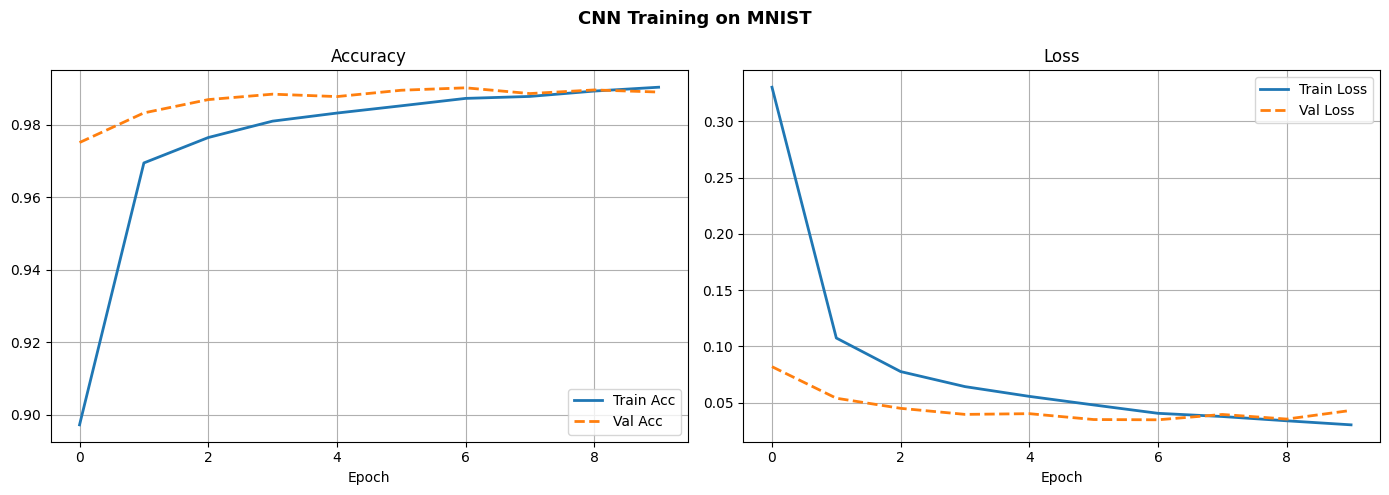

In [14]:
# ── Plot learning curves ─────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],     label='Train Acc',  linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Val Acc',    linewidth=2, linestyle='--')
ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(True)

ax2.plot(history.history['loss'],     label='Train Loss', linewidth=2)
ax2.plot(history.history['val_loss'], label='Val Loss',   linewidth=2, linestyle='--')
ax2.set_title('Loss'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(True)

plt.suptitle('CNN Training on MNIST', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()


### 1.6e — Evaluate and Inspect Predictions

In [15]:
# ── Evaluate on test set ─────────────────────────────────────────────────
test_loss, test_acc = model.evaluate(X_test, y_test_oh, verbose=0)
print(f"Test Accuracy : {test_acc*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")


Test Accuracy : 98.95%
Test Loss     : 0.0334


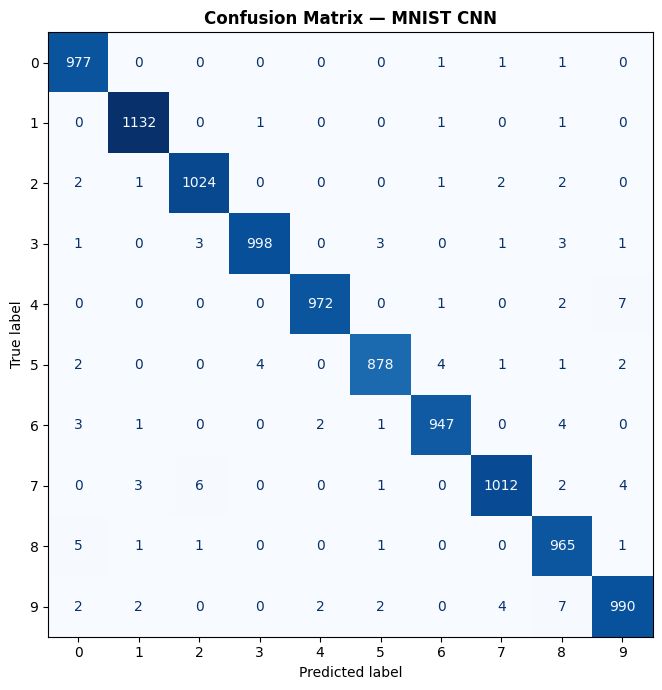

In [16]:
# ── Confusion matrix ─────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred  = np.argmax(model.predict(X_test, verbose=0), axis=1)
cm      = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title("Confusion Matrix — MNIST CNN", fontweight='bold')
plt.tight_layout(); plt.show()


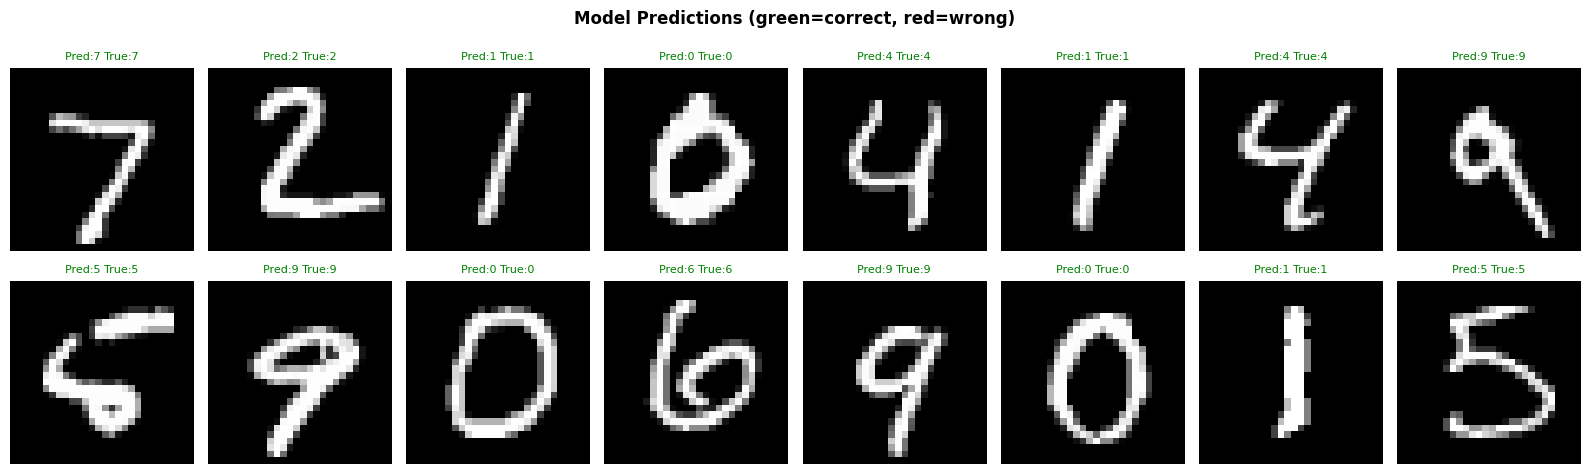

In [17]:
# ── Visualise predictions ────────────────────────────────────────────────
probs  = model.predict(X_test[:16], verbose=0)
labels = np.argmax(probs, axis=1)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(28, 28), cmap='gray')
    colour = 'green' if labels[i] == y_test[i] else 'red'
    ax.set_title(f"Pred:{labels[i]} True:{y_test[i]}", color=colour, fontsize=8)
    ax.axis('off')
plt.suptitle("Model Predictions (green=correct, red=wrong)", fontweight='bold')
plt.tight_layout(); plt.show()


---
## 1.7 Bonus — Visualising What the CNN Learned

Let's inspect the **learned filters** of the first convolutional layer.


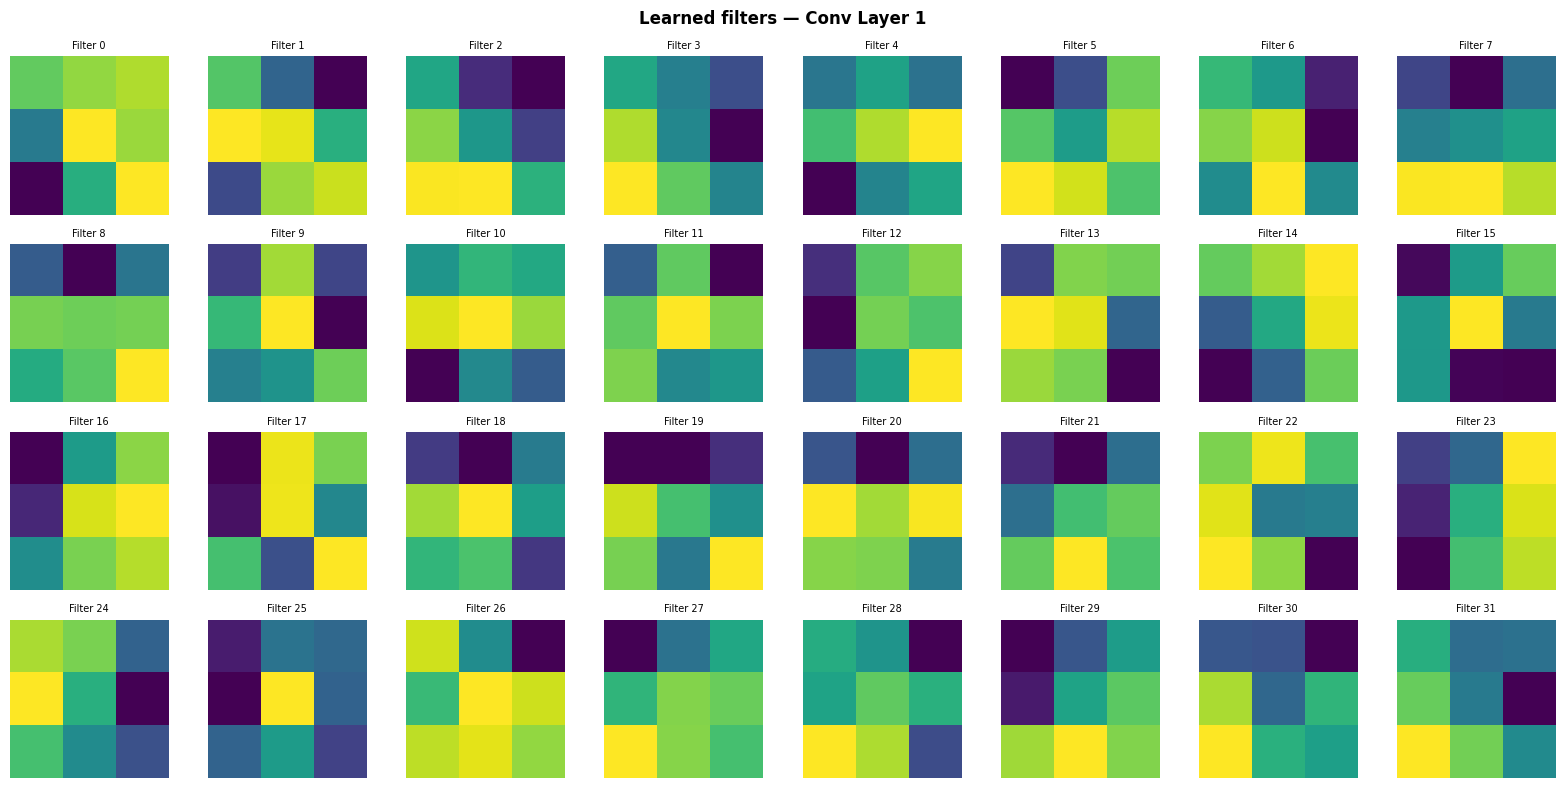

In [18]:
# ── Visualise learned Conv filters ───────────────────────────────────────
conv1_weights = model.layers[0].get_weights()[0]   # shape: (3, 3, 1, 32)
n_filters = conv1_weights.shape[-1]

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    filt = conv1_weights[:, :, 0, i]
    ax.imshow(filt, cmap='viridis')
    ax.set_title(f"Filter {i}", fontsize=7)
    ax.axis('off')
plt.suptitle("Learned filters — Conv Layer 1", fontweight='bold')
plt.tight_layout(); plt.show()


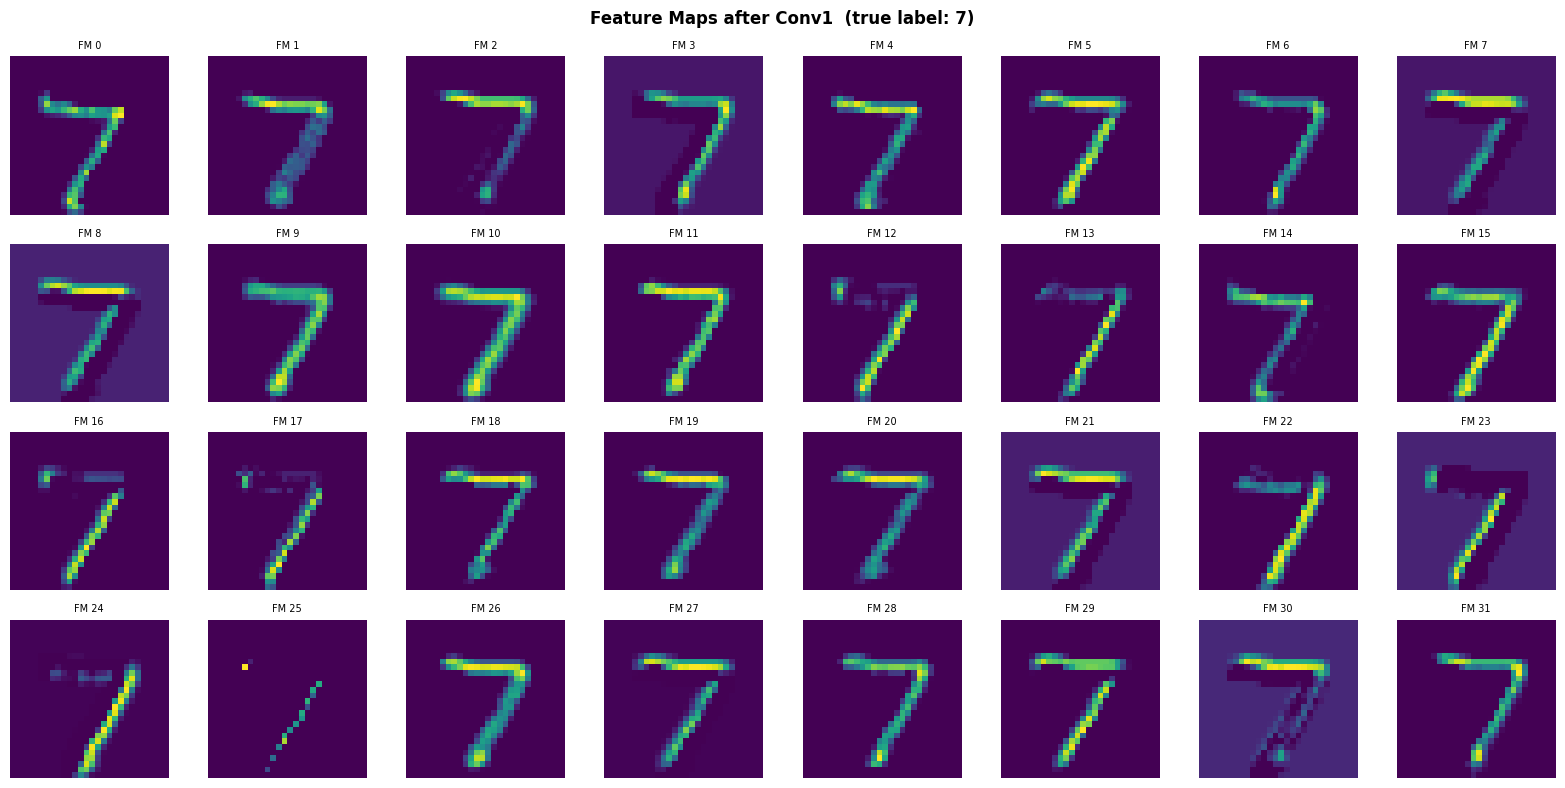

In [19]:
# ── Keras 3 compatible: build activation model with a fresh Input ─────────
# (Sequential models don't expose .input until called via Functional API)
inp_viz   = keras.Input(shape=(28, 28, 1))
out_viz   = model.layers[0](inp_viz)          # output of first Conv2D
activation_model = keras.Model(inp_viz, out_viz)

sample      = X_test[0:1]                     # shape (1, 28, 28, 1)
activations = activation_model.predict(sample, verbose=0)   # (1, 28, 28, 32)

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(activations[0, :, :, i], cmap='viridis')
    ax.set_title(f"FM {i}", fontsize=7)
    ax.axis('off')
plt.suptitle(f"Feature Maps after Conv1  (true label: {y_test[0]})", fontweight='bold')
plt.tight_layout(); plt.show()

---
### ✅ End of Part 1

**Summary of what we covered:**
- Why CNNs outperform dense networks on image data  
- Convolution: filters sliding over images to produce feature maps  
- ReLU: introducing non-linearity & fighting vanishing gradients  
- Pooling: spatial summarisation → translation invariance  
- Flattening + Dense layers: final classification  
- Building, training and evaluating a CNN on MNIST  

**Take a 10-minute break before Part 2!**


---
# PART 2 — Data Augmentation · CNN 1D · CNN 3D · Transfer Learning
---

## 2.1 Data Augmentation

Training a CNN on a small dataset often leads to **overfitting** — the network memorises training examples instead of generalising.

**Data Augmentation** artificially increases dataset size by applying random transformations:
- Horizontal/vertical flips
- Rotations
- Zoom in/out
- Shear (slant the image)
- Brightness / contrast shifts

In Keras this is done with `ImageDataGenerator` (legacy) or `tf.keras.layers.RandomFlip`, `RandomRotation`, etc. (modern).


### 📝 Task 2.1 — Build an Augmented CNN

Extend your MNIST CNN with an **augmentation block** at the input:
- `RandomRotation` factor 0.1
- `RandomZoom` height/width factor 0.1
- `RandomTranslation` height/width factor 0.1

Then retrain and compare accuracy with the baseline.


In [20]:
# ── Task 2.1 ─────────────────────────────────────────────────────────────

def build_cnn_augmented(input_shape=(28, 28, 1), num_classes=10):
    model = models.Sequential(name="MNIST_CNN_Augmented")
    
    # TODO: add augmentation layers here
    # layers.RandomRotation(...)
    # layers.RandomZoom(...)
    # layers.RandomTranslation(...)
    
    # TODO: add the same conv blocks as in Task 1.6a
    
    return model

model_aug = build_cnn_augmented()
model_aug.summary()


Model: "MNIST_CNN_Augmented"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
# TODO: compile and train the augmented model for 10 epochs
# Compare validation accuracy against `model` from Part 1



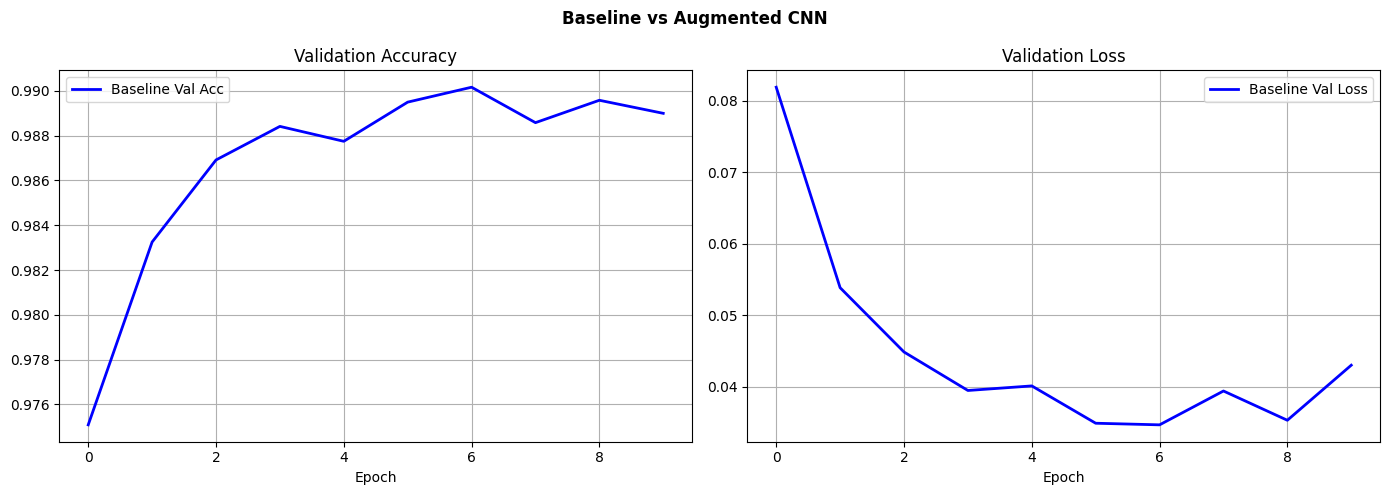

In [22]:
# ── Side-by-side learning curves ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, hist, colour in [("Baseline", history, 'blue'), ("Augmented", None, 'orange')]:
    # TODO: replace `None` above with the history of the augmented model
    if hist is None:
        continue
    axes[0].plot(hist.history['val_accuracy'], label=f'{name} Val Acc', color=colour, linewidth=2)
    axes[1].plot(hist.history['val_loss'],     label=f'{name} Val Loss', color=colour, linewidth=2)

for ax in axes:
    ax.legend(); ax.grid(True); ax.set_xlabel('Epoch')
axes[0].set_title('Validation Accuracy'); axes[1].set_title('Validation Loss')
plt.suptitle("Baseline vs Augmented CNN", fontweight='bold')
plt.tight_layout(); plt.show()


---
## 2.2 CNN 1D — ECG Arrhythmia Classification

CNNs are not limited to 2D images. A **1D convolution** slides a filter of length $k$
along the *time axis* of a signal:

$$\text{FeatureMap}[t] = \sum_{i=0}^{k-1} x[t+i] \cdot w[i]$$

### Why ECG?

The ECG (electrocardiogram) records the electrical activity of the heart over time.
Each heartbeat produces a characteristic waveform:
- **P wave** — atrial depolarisation
- **QRS complex** — ventricular depolarisation (the sharp spike)
- **T wave** — ventricular repolarisation

Arrhythmias alter the *shape* and *timing* of these components in well-defined ways.
A 1D CNN learns to detect these morphological patterns directly from raw samples —
exactly the same way a 2D CNN detects edges in an image.

### Dataset: ECG5000 (UCR Time Series Archive)

| Property | Value |
|----------|-------|
| Source | MIT-BIH Arrhythmia Database (pre-segmented by PhysioNet) |
| Total samples | 5,000 heartbeats |
| Timesteps / beat | 140 samples (~0.39 s at 360 Hz) |
| Task | 5-class arrhythmia classification |

| Class | Name | Clinical meaning |
|-------|------|-----------------|
| 0 | Normal (N) | Normal sinus rhythm |
| 1 | R-on-T PVC | Premature beat on the T wave — risk of ventricular fibrillation |
| 2 | PVC | Premature Ventricular Contraction |
| 3 | SP/EB | Supraventricular / Ectopic Beat |
| 4 | Unclassified | Does not fit other categories |

> ⚠️ **Class imbalance**: Normal beats = 58% of the data.  
> A naïve classifier that always predicts "Normal" scores 58.4% — yet misses every arrhythmia.  
> We will handle this with `class_weight` and evaluate with precision/recall/F1.


In [28]:
# ── Download ECG5000 from the UCR Time Series Archive ─────────────────────────
# No external libraries needed — pure Python urllib + zipfile.
# The dataset is ~10 MB and downloads in a few seconds.

import urllib.request
import zipfile
import io

print("Downloading ECG5000...")
url = "https://www.timeseriesclassification.com/aeon-toolkit/ECG5000.zip"

with urllib.request.urlopen(url, timeout=30) as response:
    zip_bytes = response.read()

print(f"Downloaded {len(zip_bytes) / 1024:.0f} KB")

# ── Parse UCR plain-text format ───────────────────────────────────────────────
# Each line: <label> <v1> <v2> ... <v140>
# Labels are 1-indexed floats (1.0 – 5.0)

with zipfile.ZipFile(io.BytesIO(zip_bytes)) as zf:
    train_txt = zf.read("ECG5000_TRAIN.txt").decode()
    test_txt  = zf.read("ECG5000_TEST.txt").decode()

def parse_ucr_txt(text):
    rows = [line.strip().split() for line in text.strip().split('\n') if line.strip()]
    arr  = np.array(rows, dtype=float)
    return arr[:, 1:], arr[:, 0].astype(int)   # X, y

X_tr, y_tr = parse_ucr_txt(train_txt)
X_te, y_te = parse_ucr_txt(test_txt)

# Combine train+test — we make our own stratified split below
X_all = np.concatenate([X_tr, X_te], axis=0)   # (5000, 140)
y_all = np.concatenate([y_tr, y_te], axis=0)   # (5000,) labels 1–5

print(f"\nTotal heartbeats  : {len(X_all)}")
print(f"Timesteps / beat  : {X_all.shape[1]}  (~0.39 s at 360 Hz)")
print(f"Label range       : {y_all.min()} – {y_all.max()}  (will remap to 0–4)")


Downloaded 10366 KB

Total heartbeats  : 5000
Timesteps / beat  : 140  (~0.39 s at 360 Hz)
Label range       : 1 – 5  (will remap to 0–4)


In [29]:
# ── Preprocessing ─────────────────────────────────────────────────────────────

# 1. Remap labels 1–5 → 0–4  (required by to_categorical)
y_all_0 = y_all - 1

# 2. Z-score normalisation per heartbeat
#    Removes baseline wander (DC offset) and amplitude differences between patients
mean_per_beat = X_all.mean(axis=1, keepdims=True)
std_per_beat  = X_all.std(axis=1,  keepdims=True) + 1e-8
X_norm = (X_all - mean_per_beat) / std_per_beat   # (5000, 140), zero-mean unit-variance

# 3. Add channel dimension: Conv1D expects (batch, timesteps, channels)
X_norm = X_norm[..., np.newaxis].astype('float32')  # (5000, 140, 1)

# 4. One-hot encode labels
y_oh = to_categorical(y_all_0, num_classes=5)        # (5000, 5)

# 5. Stratified 80/20 split (fixed seed for reproducibility)
rng   = np.random.RandomState(42)
idx   = rng.permutation(len(X_norm))
split = int(0.8 * len(X_norm))

X_ecg_train, X_ecg_test = X_norm[idx[:split]], X_norm[idx[split:]]
y_ecg_train, y_ecg_test = y_oh[idx[:split]],   y_oh[idx[split:]]
y_ecg_test_int          = y_all_0[idx[split:]]  # integer labels for confusion matrix

print(f"X_ecg_train : {X_ecg_train.shape}    y_ecg_train : {y_ecg_train.shape}")
print(f"X_ecg_test  : {X_ecg_test.shape}     y_ecg_test  : {y_ecg_test.shape}")

CLASS_NAMES = ["Normal (N)", "R-on-T PVC", "PVC", "SP/EB", "Unclassified"]
print("\nClass distribution (full dataset):")
for i, name in enumerate(CLASS_NAMES):
    n = int((y_all_0 == i).sum())
    print(f"  Class {i} — {name:15s}: {n:4d}  ({n/len(y_all_0)*100:.1f}%)")


X_ecg_train : (4000, 140, 1)    y_ecg_train : (4000, 5)
X_ecg_test  : (1000, 140, 1)     y_ecg_test  : (1000, 5)

Class distribution (full dataset):
  Class 0 — Normal (N)     : 2919  (58.4%)
  Class 1 — R-on-T PVC     : 1767  (35.3%)
  Class 2 — PVC            :   96  (1.9%)
  Class 3 — SP/EB          :  194  (3.9%)
  Class 4 — Unclassified   :   24  (0.5%)


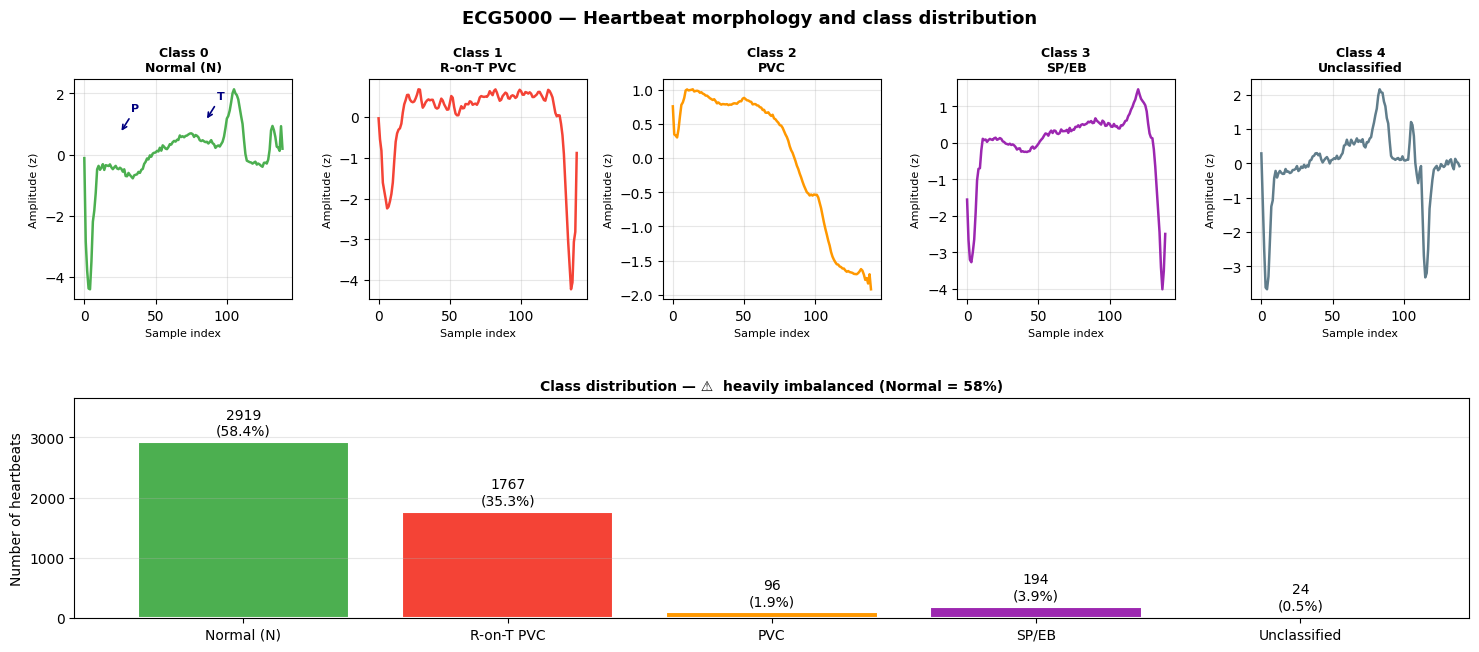

In [30]:
# ── Visualise one heartbeat per class + class distribution ────────────────────

fig = plt.figure(figsize=(18, 7))
gs  = fig.add_gridspec(2, 5, hspace=0.45, wspace=0.35)

colours    = ['#4CAF50', '#F44336', '#FF9800', '#9C27B0', '#607D8B']
ANNOTATE   = {"P": (25, 0.7), "QRS": (52, 2.6), "T": (85, 1.1)}   # approx positions
t          = np.arange(140)
found      = [False] * 5

# ── Row 1: one representative beat per class ──────────────────────────────────
for x_s, label in zip(X_norm.squeeze(), y_all_0):
    if not found[label]:
        ax = fig.add_subplot(gs[0, label])
        ax.plot(t, x_s, linewidth=1.8, color=colours[label])
        ax.set_title(f"Class {label}\n{CLASS_NAMES[label]}", fontsize=9, fontweight='bold')
        ax.set_xlabel("Sample index", fontsize=8)
        ax.set_ylabel("Amplitude (z)", fontsize=8)
        ax.grid(True, alpha=0.3)
        # Annotate ECG components on Normal beat only
        if label == 0:
            for lbl, (tx, ty) in ANNOTATE.items():
                ax.annotate(lbl, xy=(tx, ty), fontsize=8, color='navy', fontweight='bold',
                            xytext=(tx+8, ty+0.7),
                            arrowprops=dict(arrowstyle='->', color='navy', lw=1.2))
        found[label] = True
    if all(found):
        break

# ── Row 2: class distribution bar chart ───────────────────────────────────────
ax_bar = fig.add_subplot(gs[1, :])
counts = [(y_all_0 == i).sum() for i in range(5)]
bars   = ax_bar.bar(CLASS_NAMES, counts, color=colours, edgecolor='white', linewidth=1.5)
ax_bar.bar_label(bars,
                 labels=[f"{c}\n({c/sum(counts)*100:.1f}%)" for c in counts],
                 fontsize=10, padding=3)
ax_bar.set_ylabel("Number of heartbeats")
ax_bar.set_title("Class distribution — ⚠️  heavily imbalanced (Normal = 58%)",
                 fontweight='bold', fontsize=10)
ax_bar.set_ylim(0, max(counts) * 1.25)
ax_bar.grid(axis='y', alpha=0.3)

fig.suptitle("ECG5000 — Heartbeat morphology and class distribution",
             fontweight='bold', fontsize=13)
plt.show()


In [31]:
# ── Compute class weights to counter the class imbalance ─────────────────────
# Weight formula: total / (n_classes × count_i)
# → minority classes get a higher weight so the model is penalised more
#   for misclassifying them

from sklearn.utils.class_weight import compute_class_weight

y_train_int = np.argmax(y_ecg_train, axis=1)   # one-hot → integer

cw_array    = compute_class_weight('balanced', classes=np.arange(5), y=y_train_int)
class_weight_dict = {i: w for i, w in enumerate(cw_array)}

print("Class weights (higher → model penalised more for errors on that class):")
for i, (name, w) in enumerate(zip(CLASS_NAMES, cw_array)):
    print(f"  Class {i} — {name:15s}: {w:.2f}")


Class weights (higher → model penalised more for errors on that class):
  Class 0 — Normal (N)     : 0.34
  Class 1 — R-on-T PVC     : 0.56
  Class 2 — PVC            : 11.94
  Class 3 — SP/EB          : 5.00
  Class 4 — Unclassified   : 44.44


### 📝 Task 2.2 — Build the ECG 1D CNN

Build a `Conv1D` classifier for ECG arrhythmia detection.

| Layer | Type | Parameters |
|-------|------|-----------|
| 1 | Conv1D | 32 filters, kernel_size=7, ReLU, same padding |
| 2 | MaxPooling1D | pool_size=2 |
| 3 | Conv1D | 64 filters, kernel_size=5, ReLU, same padding |
| 4 | MaxPooling1D | pool_size=2 |
| 5 | Conv1D | 128 filters, kernel_size=3, ReLU, same padding |
| 6 | GlobalAveragePooling1D | — |
| 7 | Dense | 64 units, ReLU |
| 8 | Dropout | rate=0.4 |
| 9 | Dense | 5 units, Softmax |

> **Why `kernel_size=7` for the first layer?**  
> At 360 Hz, 7 samples ≈ 19 ms — enough to capture the start of a QRS complex.

> **Why `GlobalAveragePooling1D` instead of `Flatten`?**  
> It averages over all timesteps → fixed-size output regardless of sequence length,
> and ~30× fewer parameters than Flatten + Dense.


In [32]:
# ── Task 2.2a — Define the 1D CNN architecture ────────────────────────────────

def build_cnn_1d_ecg(input_shape=(140, 1), num_classes=5):
    model = models.Sequential(name="CNN_1D_ECG")

    # TODO: add the layers from the table above
    # Hint: same pattern as Conv2D but use Conv1D, MaxPooling1D, GlobalAveragePooling1D
    model.add(keras.layers.Conv1D(32,kernel_size=7, activation='relu',padding='same',input_shape=input_shape))
    model.add(keras.layers.MaxPool1D(pool_size=2))

    model.add(keras.layers.Conv1D(64,kernel_size=5, activation='relu',padding='same'))
    model.add(keras.layers.MaxPool1D(pool_size=2))
    
    model.add(keras.layers.Conv1D(128,kernel_size=3, activation='relu',padding='same'))
    model.add(keras.layers.GlobalAveragePooling1D())
   
    model.add(keras.layers.Dense(64, activation='relu')) 
    model.add(keras.layers.Dropout(rate=0.4))
    model.add(keras.layers.Dense(5, activation='softmax'))
    
    return model

model_ecg = build_cnn_1d_ecg()
model_ecg.summary()


Model: "CNN_1D_ECG"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 140, 32)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 70, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 70, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 35, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 35, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,845 (171.27 KB)

 Trainable params: 43,845 (171.27 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
# ── Task 2.2b — Compile and train ────────────────────────────────────────────

# TODO: compile with Adam (lr=5e-4), categorical_crossentropy, accuracy
model_ecg.compile(optimizer=keras.optimizers.Adam(learning_rate=5e-4), loss='categorical_crossentropy', metrics=['accuracy'])
# TODO: train for 30 epochs, batch_size=64, validation_split=0.2
# Pass class_weight=class_weight_dict to model.fit() to handle imbalance
history_ecg = model_ecg.fit(
    X_ecg_train, y_ecg_train,
    epochs=30,               # more epochs: ECG morphology is subtler than MNIST digits
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weight_dict,   # upweight minority arrhythmia classes
    verbose=1
)   


Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.3516 - loss: 1.5704 - val_accuracy: 0.8913 - val_loss: 1.5084
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6934 - loss: 1.5491 - val_accuracy: 0.8675 - val_loss: 1.4435
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6231 - loss: 1.4616 - val_accuracy: 0.8888 - val_loss: 1.0757
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8006 - loss: 1.3845 - val_accuracy: 0.6963 - val_loss: 0.9716
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7887 - loss: 1.3367 - val_accuracy: 0.8712 - val_loss: 0.9682
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7994 - loss: 1.2825 - val_accuracy: 0.9025 - val_loss: 0.8092
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7816 - loss: 1.2602 - val_accuracy: 0.9038 - val_loss: 0.8141
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7934 - loss: 1.2347 - val_accuracy: 0.8050 - val_l

ECG 1D CNN Test Accuracy  : 81.10%
Naïve baseline (all Normal): 58.40%


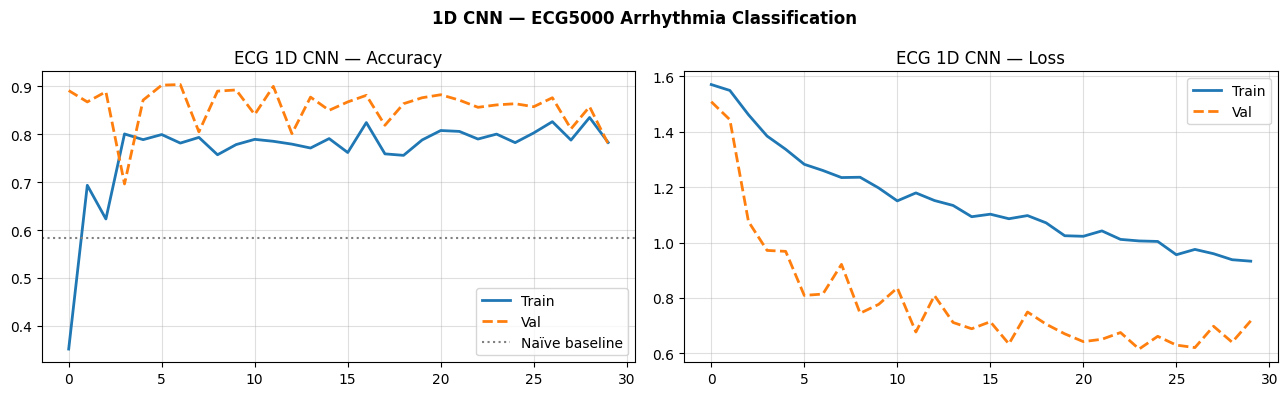

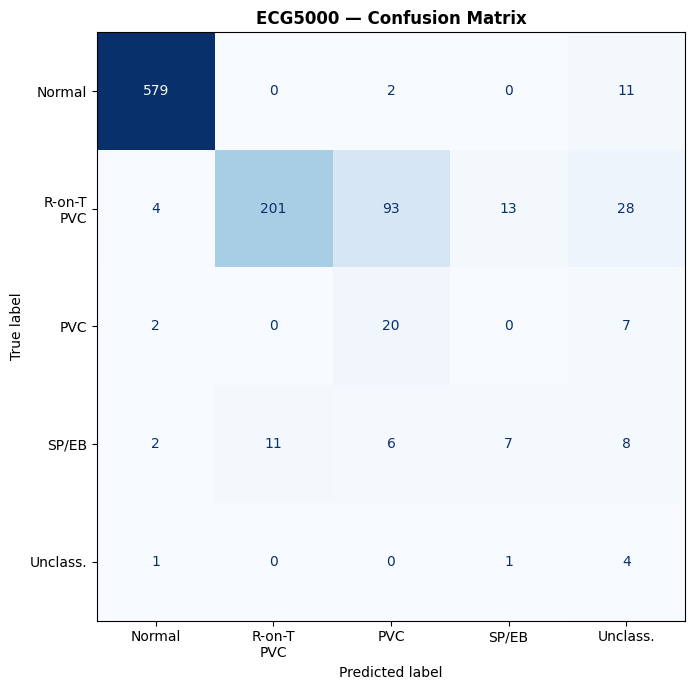


Classification Report:
──────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

  Normal (N)       0.98      0.98      0.98       592
  R-on-T PVC       0.95      0.59      0.73       339
         PVC       0.17      0.69      0.27        29
       SP/EB       0.33      0.21      0.25        34
Unclassified       0.07      0.67      0.12         6

    accuracy                           0.81      1000
   macro avg       0.50      0.63      0.47      1000
weighted avg       0.92      0.81      0.85      1000



In [45]:
# ── Evaluate: accuracy + confusion matrix + classification report ──────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

loss_ecg, acc_ecg = model_ecg.evaluate(X_ecg_test, y_ecg_test, verbose=0)
print(f"ECG 1D CNN Test Accuracy  : {acc_ecg * 100:.2f}%")
print(f"Naïve baseline (all Normal): 58.40%")

# Learning curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(history_ecg.history['accuracy'],     label='Train', linewidth=2)
ax1.plot(history_ecg.history['val_accuracy'], label='Val',   linewidth=2, linestyle='--')
ax1.axhline(0.584, color='gray', linestyle=':', linewidth=1.5, label='Naïve baseline')
ax1.set_title('ECG 1D CNN — Accuracy'); ax1.legend(); ax1.grid(True, alpha=0.4)
ax2.plot(history_ecg.history['loss'],     label='Train', linewidth=2)
ax2.plot(history_ecg.history['val_loss'], label='Val',   linewidth=2, linestyle='--')
ax2.set_title('ECG 1D CNN — Loss'); ax2.legend(); ax2.grid(True, alpha=0.4)
plt.suptitle('1D CNN — ECG5000 Arrhythmia Classification', fontweight='bold')
plt.tight_layout(); plt.show()

# Confusion matrix
y_pred     = np.argmax(model_ecg.predict(X_ecg_test, verbose=0), axis=1)
short_names = ["Normal", "R-on-T\nPVC", "PVC", "SP/EB", "Unclass."]
cm         = confusion_matrix(y_ecg_test_int, y_pred)
fig, ax    = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(cm, display_labels=short_names).plot(
    ax=ax, colorbar=False, cmap='Blues', xticks_rotation=0)
ax.set_title("ECG5000 — Confusion Matrix", fontweight='bold')
plt.tight_layout(); plt.show()

# Classification report: precision, recall, F1 per class
print("\nClassification Report:")
print("─" * 62)
print(classification_report(y_ecg_test_int, y_pred,
                             target_names=CLASS_NAMES, zero_division=0))


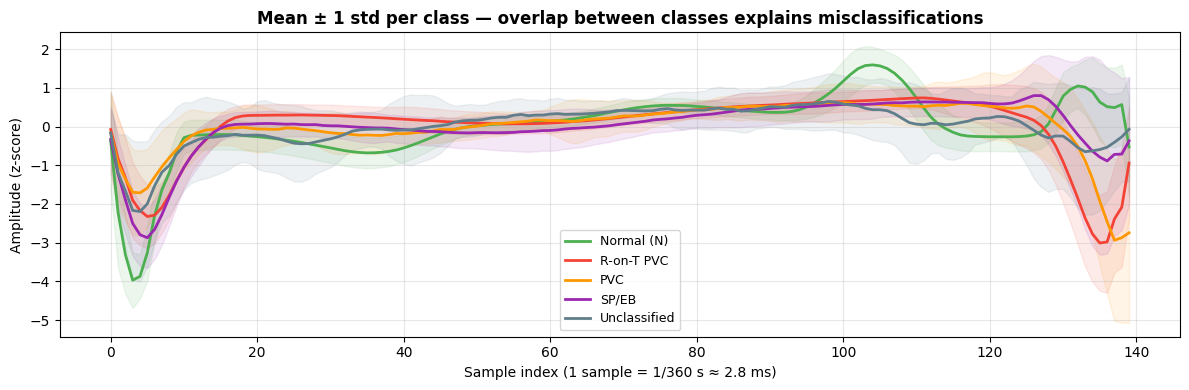

In [46]:
# ── Bonus: mean waveform ± std per class ──────────────────────────────────────
# Shows why some classes are harder to separate than others.

fig, ax = plt.subplots(figsize=(12, 4))
colours = ['#4CAF50', '#F44336', '#FF9800', '#9C27B0', '#607D8B']

for cls in range(5):
    mask      = (y_all_0 == cls)
    mean_beat = X_norm.squeeze()[mask].mean(axis=0)
    std_beat  = X_norm.squeeze()[mask].std(axis=0)
    ax.plot(mean_beat, label=CLASS_NAMES[cls], color=colours[cls], linewidth=2)
    ax.fill_between(np.arange(140),
                    mean_beat - std_beat,
                    mean_beat + std_beat,
                    color=colours[cls], alpha=0.10)

ax.set_xlabel("Sample index (1 sample = 1/360 s ≈ 2.8 ms)")
ax.set_ylabel("Amplitude (z-score)")
ax.set_title("Mean ± 1 std per class — overlap between classes explains misclassifications",
             fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


---
## 2.3 CNN 3D — Volumetric Data

A **3D CNN** adds a third spatial dimension:

| Data type | Input shape | Filter slides over |
|-----------|-------------|--------------------|
| Image (2D) | (H, W, C) | height × width |
| Video / MRI (3D) | (D, H, W, C) | depth × height × width |

Applications:
- Medical imaging (CT/MRI volume classification)
- Video action recognition
- 3D object detection (LiDAR point clouds)

Key layers in Keras: `Conv3D`, `MaxPooling3D`, `GlobalAveragePooling3D`


In [ ]:
# ── Generate synthetic volumetric dataset ────────────────────────────────
def generate_3d_dataset(n_samples=400, vol_size=16, n_classes=2):
    """
    Two classes of 3D volumes (16×16×16×1):
      0 — Gaussian blob centred at the middle
      1 — Two smaller blobs offset from centre
    """
    X, y = [], []
    cx, cy, cz = vol_size//2, vol_size//2, vol_size//2
    grid = np.indices((vol_size, vol_size, vol_size)).astype('float32')
    
    for _ in range(n_samples):
        label = np.random.randint(0, n_classes)
        noise = np.random.normal(0, 0.05, (vol_size,)*3).astype('float32')
        if label == 0:
            dist  = np.sqrt(((grid[0]-cx)**2 + (grid[1]-cy)**2 + (grid[2]-cz)**2))
            vol   = np.exp(-dist**2 / (2 * (vol_size//4)**2)) + noise
        else:
            d1 = np.sqrt(((grid[0]-cx+3)**2 + (grid[1]-cy+3)**2 + (grid[2]-cz)**2))
            d2 = np.sqrt(((grid[0]-cx-3)**2 + (grid[1]-cy-3)**2 + (grid[2]-cz)**2))
            vol = (np.exp(-d1**2/12) + np.exp(-d2**2/12)) + noise
        X.append(vol)
        y.append(label)
    
    X_arr = np.array(X)[..., np.newaxis].astype('float32')
    y_arr = to_categorical(np.array(y), n_classes)
    return X_arr, y_arr

X_3d, y_3d = generate_3d_dataset()
split = int(0.8 * len(X_3d))
X_3d_train, X_3d_test = X_3d[:split], X_3d[split:]
y_3d_train, y_3d_test = y_3d[:split], y_3d[split:]
print(f"3D volume shape: {X_3d.shape}  →  (samples, D, H, W, channels)")

# Visualise a central slice
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for i, ax in enumerate(axes):
    label = np.argmax(y_3d[i])
    ax.imshow(X_3d[i, 8, :, :, 0], cmap='hot')
    ax.set_title(f"Class {label} — central slice Z=8")
    ax.axis('off')
plt.suptitle("3D Volume Dataset (central axial slice)", fontweight='bold')
plt.tight_layout(); plt.show()


### 📝 Task 2.3 — Build a 3D CNN

Build a 3D CNN to classify the synthetic volumetric data.

| Layer | Type | Parameters |
|-------|------|-----------|
| 1 | Conv3D | 16 filters, kernel_size=(3,3,3), ReLU, same padding |
| 2 | MaxPooling3D | pool_size=(2,2,2) |
| 3 | Conv3D | 32 filters, kernel_size=(3,3,3), ReLU, same padding |
| 4 | GlobalAveragePooling3D | — |
| 5 | Dense | 64 units, ReLU |
| 6 | Dense | 2 units, Softmax |


In [ ]:
# ── Task 2.3 ─────────────────────────────────────────────────────────────

def build_cnn_3d(input_shape=(16, 16, 16, 1), num_classes=2):
    model = models.Sequential(name="CNN_3D")
    
    # TODO: add layers according to the table above
    
    return model

model_3d = build_cnn_3d()
model_3d.summary()


In [ ]:
# TODO: compile and train for 20 epochs, batch_size=32, 20% validation split
# Store history in `history_3d`
history_3d = None



In [ ]:
# ── Evaluate ──────────────────────────────────────────────────────────────
if history_3d:
    loss_3d, acc_3d = model_3d.evaluate(X_3d_test, y_3d_test, verbose=0)
    print(f"3D CNN Test Accuracy: {acc_3d*100:.2f}%")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history_3d.history['accuracy'],     label='Train', linewidth=2)
    ax1.plot(history_3d.history['val_accuracy'], label='Val',   linewidth=2, linestyle='--')
    ax1.set_title('3D CNN — Accuracy'); ax1.legend(); ax1.grid(True)
    ax2.plot(history_3d.history['loss'],     label='Train', linewidth=2)
    ax2.plot(history_3d.history['val_loss'], label='Val',   linewidth=2, linestyle='--')
    ax2.set_title('3D CNN — Loss'); ax2.legend(); ax2.grid(True)
    plt.tight_layout(); plt.show()


---
## 2.4 CNN Dimensions — Summary

| Dimension | Keras Layer | Input shape | Typical use case |
|-----------|-------------|-------------|-----------------|
| **1D** | `Conv1D` | `(batch, steps, features)` | Time series, audio, text |
| **2D** | `Conv2D` | `(batch, H, W, channels)` | Images |
| **3D** | `Conv3D` | `(batch, D, H, W, channels)` | Video, MRI/CT volumes |

> In all cases the **same building blocks** apply: convolution → activation → pooling → flatten/GAP → dense.


---
## 2.5 Transfer Learning (Conceptual Overview)

Training deep CNNs from scratch requires:
- **Millions** of labelled images
- **Days** of GPU compute

**Transfer learning** lets us reuse a pretrained network (e.g. trained on ImageNet with 1.3M images) as a starting point.

### Workflow

1. **Load** a pretrained backbone (e.g. `InceptionV3`, `VGG16`, `ResNet50`)  
2. **Freeze** the backbone weights (keep the learned features)  
3. **Add** a new classification head for your task  
4. **Fine-tune** only the new head (or optionally unfreeze the top layers of the backbone)

```python
# Example sketch
base_model = keras.applications.InceptionV3(
    weights='imagenet',
    include_top=False,         # remove original classification head
    input_shape=(224, 224, 3)
)
base_model.trainable = False   # freeze backbone

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(256, activation='relu')(x)
out = layers.Dense(num_classes, activation='softmax')(x)

model_tl = keras.Model(base_model.input, out)
```


### 📝 Task 2.5 — Transfer Learning with MobileNetV2

Use `MobileNetV2` (pretrained on ImageNet, ~3.4M parameters, very fast) as a backbone  
to classify MNIST digits.  

> **Note:** ImageNet-pretrained models expect 3-channel (RGB) input ≥ 32×32.  
> We'll resize MNIST images to 32×32 and repeat the single channel 3 times.


In [ ]:
# ── Task 2.5 ─────────────────────────────────────────────────────────────
from torch import optim

# Resize MNIST to 32×32 RGB (required by MobileNetV2)
X_train_rgb = tf.image.resize(np.repeat(X_train, 3, axis=-1), [32, 32]).numpy()
X_test_rgb  = tf.image.resize(np.repeat(X_test,  3, axis=-1), [32, 32]).numpy()

# TODO: load MobileNetV2 with imagenet weights, include_top=False, input_shape=(32,32,3)
base_model = keras.applications.MobileNetV2(
    weights='imagenet',
    include_top=False,         # remove original classification head
    input_shape=(32, 32, 3)
)

# TODO: freeze the backbone
base_model.trainable = False   # freeze backbone

# TODO: add a classification head using Keras Functional API
# Hint: GlobalAveragePooling2D → Dense(64, relu) → Dense(10, softmax)
inputs = keras.Input(shape=(32,32,3))
x = base_model(inputs, training= False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, action='relu')(x)
outputs= layers.Dense(10, activation='softmax')(x)

model_tl = keras.Model(input=inputs, outputs=outputs, name='MobileNetV2_MNIST')
model_tl.compile(optimizer= )

# TODO: create the model, compile and train for 5 epochs (fine-tuning only the head)
# This should train quickly and still reach >95% accuracy!



In [ ]:
# ── Collect results from all models ──────────────────────────────────────────
results = {}

try: results['CNN Baseline\n(MNIST)']  = model.evaluate(X_test, y_test_oh, verbose=0)[1]
except: pass
try: results['CNN Augmented\n(MNIST)'] = model_aug.evaluate(X_test, y_test_oh, verbose=0)[1]
except: pass
try: results['CNN 1D\n(ECG 5-class)']  = model_ecg.evaluate(X_ecg_test, y_ecg_test, verbose=0)[1]
except: pass
try: results['CNN 3D\n(Volumes)']      = model_3d.evaluate(X_3d_test, y_3d_test, verbose=0)[1]
except: pass
try: results['Transfer\nMobileNetV2']  = model_tl.evaluate(X_test_rgb, y_test_oh, verbose=0)[1]
except: pass

if results:
    fig, ax = plt.subplots(figsize=(13, 5))
    colours = ['#2196F3','#FF9800','#F44336','#9C27B0','#4CAF50']
    bars = ax.bar(results.keys(), [v*100 for v in results.values()],
                  color=colours[:len(results)], edgecolor='white', linewidth=1.5, width=0.5)
    ax.bar_label(bars, fmt='%.2f%%', fontsize=11, padding=4)
    # ECG naïve baseline reference line
    if 'CNN 1D\n(ECG 5-class)' in results:
        ax.axhline(58.4, color='#F44336', linestyle='--', linewidth=1.2, alpha=0.6)
        ax.text(1.6, 60, "ECG naïve baseline 58.4%", color='#F44336', fontsize=8)
    ax.set_ylabel('Test Accuracy (%)'); ax.set_ylim(0, 112)
    ax.set_title('All Models — Test Accuracy', fontweight='bold', fontsize=13)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

    print("\nFinal Results:")
    print("─" * 50)
    for name, acc in results.items():
        print(f"  {name.replace(chr(10),' '):35s}: {acc*100:.2f}%")


---
### ✅ End of Part 2 — Congratulations!

**Summary of what we covered:**

| Topic | Key takeaway |
|-------|-------------|
| Data Augmentation | Reduces overfitting — random transforms at training time only |
| CNN 1D (ECG) | Same building blocks applied to temporal biomedical signals |
| Class imbalance | Accuracy alone is misleading — use class weights + F1/recall |
| CNN 3D | Extends spatial convolution to volumetric data (video, MRI/CT) |
| Transfer Learning | Pretrained backbone → dramatic reduction in data & compute needs |

**Further reading:**
- LeCun et al. (1998) — *Gradient-based learning applied to document recognition*
- Hannun et al. (2019) — *Cardiologist-level arrhythmia detection with CNN* (Nature Medicine)
- Kuo (2016) — *Understanding CNNs with a Mathematical Model*
- Scherer et al. (2010) — *Evaluation of Pooling Operations*
- Deshpande (2016) — *The 9 Deep Learning Papers You Need To Know About*
